<a href="https://colab.research.google.com/github/StrionZZZ/BMKG-AFIF/blob/main/UAS_DATA_Mining_SepsisAI_Colab_Afif_157.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Data Mining Kesehatan
## SepsisAI Mini - LSTM + Warning-Alert Web App

Notebook ini dibuat untuk Google Colab dan disesuaikan dengan dataset pengguna di Google Drive:

`/content/drive/MyDrive/File Tugas/Semester 6/Data Mining Kesehatan/Sepsis Dataset.zip`

Fokus notebook:
1. membaca dataset sepsis dari ZIP;
2. preprocessing time-series per pasien;
3. membuat fitur turunan klinis;
4. membuat sliding window 4 jam;
5. melatih model LSTM;
6. mengevaluasi time-level dan patient-level;
7. menerapkan SepsisAI Warning-Alert: warning jika probabilitas >= 0.5, alert jika ada 3 warning dalam 5 jam;
8. menyediakan web Gradio untuk demo UAS.

Catatan: sistem ini hanya prototype akademik, bukan alat diagnosis medis.

## Cell 1 - Install Library
Jalankan sekali di Google Colab.

In [1]:
!pip install -q gradio

## Cell 2 - Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 - Konfigurasi

In [3]:
import os
import glob
import zipfile
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset asli dari Google Drive.
USE_SYNTHETIC_DATA = False

DATA_ZIP_PATH = '/content/drive/MyDrive/File Tugas/Semester 6/Data Mining Kesehatan/Sepsis Dataset.zip'
EXTRACT_DIR = '/content/sepsis_dataset'
ARTIFACT_DIR = '/content/drive/MyDrive/File Tugas/Semester 6/Data Mining Kesehatan/sepsis_uas_artifacts'

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Parameter utama mengikuti paper SepsisAI.
WINDOW_SIZE = 4
WARNING_THRESHOLD = 0.5
ALERT_WARNING_COUNT = 3
ALERT_WINDOW_HOURS = 5

# Parameter training.
EPOCHS = 10
BATCH_SIZE = 64

# Imbalance handling: jumlah negatif training maksimal = NEG_POS_RATIO x jumlah positif.
NEG_POS_RATIO = 10

# Batch size untuk prediksi cepat.
PREDICT_BATCH_SIZE = 1024

# Batasi jumlah pasien jika ingin smoke test cepat. None berarti gunakan semua pasien.
MAX_PATIENTS = None
# Contoh smoke test: MAX_PATIENTS = 1000

if not USE_SYNTHETIC_DATA:
    if not os.path.exists(DATA_ZIP_PATH):
        raise FileNotFoundError('Dataset tidak ditemukan. Periksa DATA_ZIP_PATH: ' + DATA_ZIP_PATH)
    print('Dataset ditemukan:', DATA_ZIP_PATH)

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('USE_SYNTHETIC_DATA:', USE_SYNTHETIC_DATA)
print('DATA_ZIP_PATH:', DATA_ZIP_PATH)
print('EXTRACT_DIR:', EXTRACT_DIR)
print('ARTIFACT_DIR:', ARTIFACT_DIR)

Dataset ditemukan: /content/drive/MyDrive/File Tugas/Semester 6/Data Mining Kesehatan/Sepsis Dataset.zip
TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
USE_SYNTHETIC_DATA: False
DATA_ZIP_PATH: /content/drive/MyDrive/File Tugas/Semester 6/Data Mining Kesehatan/Sepsis Dataset.zip
EXTRACT_DIR: /content/sepsis_dataset
ARTIFACT_DIR: /content/drive/MyDrive/File Tugas/Semester 6/Data Mining Kesehatan/sepsis_uas_artifacts


## Cell 4 - Daftar Fitur

In [4]:
VITAL_FEATURES = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp'
]

LAB_FEATURES = [
    'WBC', 'Platelets', 'Creatinine', 'BUN',
    'Bilirubin', 'Lactate', 'Glucose', 'Hct'
]

DEMO_FEATURES = [
    'Age', 'Gender'
]

DERIVED_FEATURES = [
    'ShockIndex',
    'BUNCreatinineRatio',
    'MEWS',
    'pSOFA'
]

FEATURES = VITAL_FEATURES + LAB_FEATURES + DEMO_FEATURES + DERIVED_FEATURES
RAW_FEATURES = VITAL_FEATURES + LAB_FEATURES + DEMO_FEATURES

LABEL_COL = 'SepsisLabel'
PATIENT_COL = 'Patient_ID'

print('Jumlah fitur:', len(FEATURES))
print(FEATURES)

Jumlah fitur: 21
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'WBC', 'Platelets', 'Creatinine', 'BUN', 'Bilirubin', 'Lactate', 'Glucose', 'Hct', 'Age', 'Gender', 'ShockIndex', 'BUNCreatinineRatio', 'MEWS', 'pSOFA']


## Cell 5 - Load Dataset dari ZIP

In [5]:
def load_dataset_from_zip(data_zip_path, extract_dir):
    os.makedirs(extract_dir, exist_ok=True)

    print('Mengekstrak dataset ke:', extract_dir)
    with zipfile.ZipFile(data_zip_path, 'r') as z:
        z.extractall(extract_dir)

    csv_files = glob.glob(os.path.join(extract_dir, '**', '*.csv'), recursive=True)
    psv_files = glob.glob(os.path.join(extract_dir, '**', '*.psv'), recursive=True)

    dataset_csv = [
        f for f in csv_files
        if os.path.basename(f).lower() == 'dataset.csv'
    ]

    if dataset_csv:
        path = dataset_csv[0]
        print('Membaca Dataset.csv:', path)
        return pd.read_csv(path)

    if csv_files:
        path = csv_files[0]
        print('Dataset.csv tidak ditemukan. Membaca CSV pertama:', path)
        return pd.read_csv(path)

    if psv_files:
        print('Membaca file PSV:', len(psv_files))
        frames = []

        for idx, path in enumerate(psv_files):
            if idx % 500 == 0:
                print(f'Membaca PSV ke-{idx + 1}/{len(psv_files)}')

            temp = pd.read_csv(path, sep='|')
            patient_id = os.path.splitext(os.path.basename(path))[0]
            temp[PATIENT_COL] = patient_id
            frames.append(temp)

        return pd.concat(frames, ignore_index=True)

    raise FileNotFoundError('Tidak ditemukan file CSV atau PSV di dalam ZIP dataset.')


raw_df = load_dataset_from_zip(DATA_ZIP_PATH, EXTRACT_DIR)

if MAX_PATIENTS is not None:
    # Sampling patient-level untuk smoke test cepat.
    if PATIENT_COL in raw_df.columns:
        unique_ids = raw_df[PATIENT_COL].dropna().unique()
        keep_ids = np.random.default_rng(SEED).choice(
            unique_ids,
            size=min(MAX_PATIENTS, len(unique_ids)),
            replace=False
        )
        raw_df = raw_df[raw_df[PATIENT_COL].isin(keep_ids)].copy()
    else:
        print('MAX_PATIENTS diabaikan karena Patient_ID belum tersedia sebelum standardisasi.')

print('Shape raw_df:', raw_df.shape)
display(raw_df.head())
print(raw_df.columns.tolist())

Mengekstrak dataset ke: /content/sepsis_dataset
Membaca Dataset.csv: /content/sepsis_dataset/Dataset.csv
Shape raw_df: (1552210, 44)


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


## Cell 6 - Standardisasi Kolom

In [22]:
def coalesce_columns(df, candidates):
    """
    Mengambil satu kolom dari beberapa kandidat nama kolom.
    Aman untuk kasus kolom duplikat seperti Hour dan ICULOS.
    """
    candidates = [str(c).strip() for c in candidates]

    matched_indices = []
    for i, col in enumerate(df.columns):
        col_name = str(col).strip()
        if col_name in candidates:
            matched_indices.append(i)

    if len(matched_indices) == 0:
        return None

    temp = df.iloc[:, matched_indices]

    if temp.shape[1] == 1:
        return temp.iloc[:, 0]

    # Jika ada lebih dari satu kolom kandidat, ambil nilai non-null pertama per baris
    return temp.bfill(axis=1).iloc[:, 0]


def standardize_columns(df):
    """
    Membuat dataframe standar dengan kolom:
    Patient_ID, Hour, SepsisLabel, dan semua RAW_FEATURES.

    Fungsi ini dibuat ulang agar tidak error ketika dataset memiliki
    kolom Hour/ICULOS dobel atau nama kolom yang bervariasi.
    """
    df = df.copy()

    # Rapikan nama kolom
    df.columns = [str(c).strip() for c in df.columns]

    out = pd.DataFrame(index=df.index)

    column_candidates = {
        PATIENT_COL: [
            'Patient_ID',
            'PatientID',
            'patient_id',
            'patient',
            'Patient',
            'ID',
            'id',
            'HospAdmTime'
        ],

        'Hour': [
            'Hour',
            'hour',
            'Time',
            'time',
            'ICULOS',
            'iculos'
        ],

        LABEL_COL: [
            'SepsisLabel',
            'Sepsis_Label',
            'sepsis_label',
            'Label',
            'label',
            'Sepsis',
            'sepsis'
        ],

        'HR': [
            'HR',
            'HeartRate',
            'Heart_Rate',
            'heart_rate'
        ],

        'O2Sat': [
            'O2Sat',
            'O2sat',
            'OxygenSaturation',
            'oxygen_saturation',
            'SpO2',
            'spo2'
        ],

        'Temp': [
            'Temp',
            'Temperature',
            'temperature'
        ],

        'SBP': [
            'SBP',
            'SystolicBP',
            'Systolic_BP',
            'systolic_bp'
        ],

        'MAP': [
            'MAP',
            'MeanArterialPressure',
            'Mean_Arterial_Pressure'
        ],

        'DBP': [
            'DBP',
            'DiastolicBP',
            'Diastolic_BP',
            'diastolic_bp'
        ],

        'Resp': [
            'Resp',
            'RespRate',
            'RespiratoryRate',
            'respiratory_rate'
        ],

        'WBC': [
            'WBC',
            'WhiteBloodCell',
            'White_Blood_Cell'
        ],

        'Platelets': [
            'Platelets',
            'Platelet',
            'PlateletCount',
            'platelets'
        ],

        'Creatinine': [
            'Creatinine',
            'Creat',
            'creatinine'
        ],

        'BUN': [
            'BUN',
            'bun'
        ],

        'Bilirubin': [
            'Bilirubin',
            'Bilirubin_total',
            'BilirubinTotal',
            'TotalBilirubin',
            'bilirubin'
        ],

        'Lactate': [
            'Lactate',
            'lactate'
        ],

        'Glucose': [
            'Glucose',
            'glucose'
        ],

        'Hct': [
            'Hct',
            'Hematocrit',
            'hematocrit'
        ],

        'Age': [
            'Age',
            'age'
        ],

        'Gender': [
            'Gender',
            'gender',
            'Sex',
            'sex'
        ],
    }

    for canonical_name, candidates in column_candidates.items():
        series = coalesce_columns(df, candidates)

        if series is not None:
            out[canonical_name] = series

    # Jika Patient_ID tidak ada, buat satu pasien default
    if PATIENT_COL not in out.columns:
        print('Peringatan: Patient_ID tidak ditemukan. Semua baris dianggap satu pasien.')
        out[PATIENT_COL] = 'patient_0'

    # Jika Hour tidak ada, buat urutan jam per pasien
    if 'Hour' not in out.columns:
        out['Hour'] = out.groupby(PATIENT_COL).cumcount()

    # Jika label tidak ada, buat 0
    if LABEL_COL not in out.columns:
        print('Peringatan: SepsisLabel tidak ditemukan. Label dibuat 0.')
        out[LABEL_COL] = 0

    # Pastikan semua raw features tersedia
    for col in RAW_FEATURES:
        if col not in out.columns:
            print(f'Peringatan: kolom {col} tidak ditemukan. Diisi NaN.')
            out[col] = np.nan

    # Konversi Patient_ID ke string
    out[PATIENT_COL] = out[PATIENT_COL].astype(str)

    # Konversi Hour ke numerik
    hour_series = out['Hour']

    # Safety check: kalau masih DataFrame, ambil kolom pertama
    if isinstance(hour_series, pd.DataFrame):
        hour_series = hour_series.iloc[:, 0]

    out['Hour'] = pd.to_numeric(hour_series, errors='coerce')

    # Isi Hour kosong dengan urutan per pasien
    generated_hour = out.groupby(PATIENT_COL).cumcount()
    out['Hour'] = out['Hour'].fillna(generated_hour)
    out['Hour'] = out['Hour'].astype(int)

    # Konversi label ke integer
    label_series = out[LABEL_COL]

    if isinstance(label_series, pd.DataFrame):
        label_series = label_series.iloc[:, 0]

    out[LABEL_COL] = pd.to_numeric(label_series, errors='coerce')
    out[LABEL_COL] = out[LABEL_COL].fillna(0).astype(int)

    # Gender handling
    if 'Gender' in out.columns:
        out['Gender'] = out['Gender'].replace({
            'Male': 1,
            'M': 1,
            'male': 1,
            'm': 1,
            'Female': 0,
            'F': 0,
            'female': 0,
            'f': 0
        })

    # Konversi semua fitur klinis ke numerik
    for col in RAW_FEATURES:
        series = out[col]

        if isinstance(series, pd.DataFrame):
            series = series.iloc[:, 0]

        out[col] = pd.to_numeric(series, errors='coerce')

    out = out.sort_values([PATIENT_COL, 'Hour']).reset_index(drop=True)

    return out


print('standardize_columns versi baru berhasil dimuat.')

standardize_columns versi baru berhasil dimuat.


## Cell 7 - Feature Engineering

In [18]:
def score_hr(hr):
    return np.select(
        [
            hr <= 40,
            (hr > 40) & (hr <= 50),
            (hr > 50) & (hr <= 100),
            (hr > 100) & (hr <= 110),
            (hr > 110) & (hr <= 129),
            hr > 129
        ],
        [2, 1, 0, 1, 2, 3],
        default=0
    )


def score_sbp(sbp):
    return np.select(
        [
            sbp <= 70,
            (sbp > 70) & (sbp <= 80),
            (sbp > 80) & (sbp <= 100),
            (sbp > 100) & (sbp <= 199),
            sbp > 199
        ],
        [3, 2, 1, 0, 2],
        default=0
    )


def score_resp(resp):
    return np.select(
        [
            resp < 9,
            (resp >= 9) & (resp <= 14),
            (resp > 14) & (resp <= 20),
            (resp > 20) & (resp <= 29),
            resp > 29
        ],
        [2, 0, 1, 2, 3],
        default=0
    )


def score_temp(temp):
    return np.select(
        [
            temp < 35,
            (temp >= 35) & (temp <= 38.4),
            temp > 38.4
        ],
        [2, 0, 2],
        default=0
    )


def score_creatinine(cr):
    return np.select(
        [
            cr >= 5.0,
            (cr >= 3.5) & (cr < 5.0),
            (cr >= 2.0) & (cr < 3.5),
            (cr >= 1.2) & (cr < 2.0),
            cr < 1.2
        ],
        [4, 3, 2, 1, 0],
        default=0
    )


def score_bilirubin(bili):
    return np.select(
        [
            bili >= 12,
            (bili >= 6) & (bili < 12),
            (bili >= 2) & (bili < 6),
            (bili >= 1.2) & (bili < 2),
            bili < 1.2
        ],
        [4, 3, 2, 1, 0],
        default=0
    )


def score_platelets(plt):
    return np.select(
        [
            plt < 20,
            (plt >= 20) & (plt < 50),
            (plt >= 50) & (plt < 100),
            (plt >= 100) & (plt < 150),
            plt >= 150
        ],
        [4, 3, 2, 1, 0],
        default=0
    )


def add_derived_features(df):
    df = df.copy()

    df['ShockIndex'] = df['HR'] / df['SBP'].replace(0, np.nan)
    df['BUNCreatinineRatio'] = df['BUN'] / df['Creatinine'].replace(0, np.nan)

    df['MEWS'] = (
        score_hr(df['HR']) +
        score_sbp(df['SBP']) +
        score_resp(df['Resp']) +
        score_temp(df['Temp'])
    )

    df['pSOFA'] = (
        np.where(df['MAP'] < 70, 1, 0) +
        score_creatinine(df['Creatinine']) +
        score_bilirubin(df['Bilirubin']) +
        score_platelets(df['Platelets'])
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

## Cell 8 - Preprocessing dan Normalisasi
Perbaikan utama: hanya memakai forward fill, tidak memakai backward fill.

In [23]:
MIN_MAX = {
    'HR': (30, 220),
    'O2Sat': (50, 100),
    'Temp': (30, 42),
    'SBP': (50, 220),
    'MAP': (30, 160),
    'DBP': (20, 140),
    'Resp': (5, 60),

    'WBC': (0, 50),
    'Platelets': (5, 700),
    'Creatinine': (0.1, 12),
    'BUN': (1, 120),
    'Bilirubin': (0, 30),
    'Lactate': (0, 20),
    'Glucose': (20, 500),
    'Hct': (10, 60),

    'Age': (18, 100),
    'Gender': (0, 1),

    'ShockIndex': (0.2, 3),
    'BUNCreatinineRatio': (1, 100),
    'MEWS': (0, 14),
    'pSOFA': (0, 16),
}


def preprocess_dataframe(df):
    df = standardize_columns(df)
    df = df.sort_values([PATIENT_COL, 'Hour']).reset_index(drop=True)

    # Forward fill hanya memakai data masa lalu dalam pasien yang sama.
    # Tidak memakai bfill agar tidak terjadi data leakage dari masa depan.
    for col in RAW_FEATURES:
        df[col] = df.groupby(PATIENT_COL)[col].transform(lambda s: s.ffill())

    df = add_derived_features(df)

    for col in DERIVED_FEATURES:
        df[col] = df.groupby(PATIENT_COL)[col].transform(lambda s: s.ffill())

    return df


def normalize_dataframe(df):
    out = df[[PATIENT_COL, 'Hour', LABEL_COL]].copy()

    for col in FEATURES:
        min_val, max_val = MIN_MAX[col]

        x = df[col].copy()

        if isinstance(x, pd.DataFrame):
            x = x.iloc[:, 0]

        missing_mask = x.isna()

        x = pd.to_numeric(x, errors='coerce')
        x = x.clip(min_val, max_val)
        x = 4 * (x - min_val) / (max_val - min_val) + 1
        x[missing_mask] = -1

        out[col] = x.fillna(-1)

    return out


print('preprocess_dataframe dan normalize_dataframe berhasil dimuat.')

preprocess_dataframe dan normalize_dataframe berhasil dimuat.


## Cell 9 - Proses Dataset dan Split Patient-Level

In [24]:
processed_df = preprocess_dataframe(raw_df)
normalized_df = normalize_dataframe(processed_df)

patient_labels = processed_df.groupby(PATIENT_COL)[LABEL_COL].max()
patient_ids = patient_labels.index.to_numpy()
labels_for_split = patient_labels.values


def stratified_split(ids, y, test_size, random_state):
    unique, counts = np.unique(y, return_counts=True)
    stratify = y if (len(unique) == 2 and counts.min() >= 2) else None

    return train_test_split(
        ids,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify
    )


train_ids, temp_ids = stratified_split(
    patient_ids,
    labels_for_split,
    test_size=0.30,
    random_state=SEED
)

temp_labels = patient_labels.loc[temp_ids].values

val_ids, test_ids = stratified_split(
    temp_ids,
    temp_labels,
    test_size=0.50,
    random_state=SEED
)

print('Total patients:', len(patient_ids))
print('Train patients:', len(train_ids))
print('Val patients  :', len(val_ids))
print('Test patients :', len(test_ids))

print('\nPatient-level label distribution:')
print(patient_labels.value_counts())

display(processed_df.head())

Total patients: 12157
Train patients: 8509
Val patients  : 1824
Test patients : 1824

Patient-level label distribution:
SepsisLabel
0    10616
1     1541
Name: count, dtype: int64


,Patient_ID,Hour,SepsisLabel,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,...,Bilirubin,Lactate,Glucose,Hct,Age,Gender,ShockIndex,BUNCreatinineRatio,MEWS,pSOFA
0,-0.01,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,67.00,1,NaN,NaN,0,0
1,-0.01,0,0,88.5,88.0,38.39,NaN,98.00,NaN,17.0,...,1.1,NaN,138.0,38.4,69.82,1,NaN,15.0,1,1
2,-0.01,0,0,88.5,88.0,38.39,NaN,98.00,NaN,17.0,...,1.1,NaN,138.0,38.4,59.78,0,NaN,15.0,1,1
3,-0.01,0,0,66.0,95.0,36.67,133.0,90.33,NaN,19.5,...,1.1,NaN,138.0,38.4,81.68,0,0.496241,15.0,1,1
4,-0.01,0,0,75.0,100.0,37.06,117.0,87.00,NaN,17.0,...,1.1,NaN,138.0,38.4,32.47,0,0.641026,15.0,1,1


## Cell 10 - Sliding Window

In [25]:
def make_windows(norm_df, ids):
    X_list = []
    y_list = []
    pid_list = []
    hour_list = []

    id_set = set(ids)
    df_part = norm_df[norm_df[PATIENT_COL].isin(id_set)].copy()

    for pid, g in df_part.groupby(PATIENT_COL, sort=False):
        g = g.sort_values('Hour').reset_index(drop=True)

        values = g[FEATURES].values.astype('float32')
        labels = g[LABEL_COL].values.astype('int32')
        hours = g['Hour'].values

        if len(g) < WINDOW_SIZE:
            continue

        for i in range(WINDOW_SIZE - 1, len(g)):
            X_list.append(values[i - WINDOW_SIZE + 1:i + 1])
            y_list.append(labels[i])
            pid_list.append(pid)
            hour_list.append(hours[i])

    return (
        np.array(X_list, dtype='float32'),
        np.array(y_list, dtype='int32'),
        np.array(pid_list),
        np.array(hour_list)
    )


X_train, y_train, pid_train, hour_train = make_windows(normalized_df, train_ids)
X_val, y_val, pid_val, hour_val = make_windows(normalized_df, val_ids)
X_test, y_test, pid_test, hour_test = make_windows(normalized_df, test_ids)

print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val  :', X_val.shape, 'y_val  :', y_val.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)

X_train: (1075515, 4, 21) y_train: (1075515,)
X_val  : (163397, 4, 21) y_val  : (163397,)
X_test : (276827, 4, 21) y_test : (276827,)


## Cell 11 - Cek Distribusi Label

In [26]:
def print_label_distribution(name, y):
    total = len(y)
    pos = int(np.sum(y == 1))
    neg = int(np.sum(y == 0))
    pos_pct = pos / total * 100 if total > 0 else 0

    print(name)
    print('  Total window :', total)
    print('  Negatif      :', neg)
    print('  Positif      :', pos)
    print(f'  Positif (%)  : {pos_pct:.4f}%')
    print()


print_label_distribution('Train', y_train)
print_label_distribution('Validation', y_val)
print_label_distribution('Test', y_test)

Train
  Total window : 1075515
  Negatif      : 1055803
  Positif      : 19712
  Positif (%)  : 1.8328%

Validation
  Total window : 163397
  Negatif      : 160930
  Positif      : 2467
  Positif (%)  : 1.5098%

Test
  Total window : 276827
  Negatif      : 271534
  Positif      : 5293
  Positif (%)  : 1.9120%



## Cell 12 - Undersampling Data Train
Validation dan test tidak di-undersampling.

In [27]:
def undersample_negative_windows(X, y, neg_pos_ratio=10, seed=42):
    rng = np.random.default_rng(seed)

    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    if len(pos_idx) == 0:
        raise ValueError('Tidak ada label positif pada y_train.')

    n_neg_keep = min(len(neg_idx), len(pos_idx) * neg_pos_ratio)
    sampled_neg_idx = rng.choice(neg_idx, size=n_neg_keep, replace=False)

    selected_idx = np.concatenate([pos_idx, sampled_neg_idx])
    rng.shuffle(selected_idx)

    return X[selected_idx], y[selected_idx]


X_train_bal, y_train_bal = undersample_negative_windows(
    X_train,
    y_train,
    neg_pos_ratio=NEG_POS_RATIO,
    seed=SEED
)

print('Sebelum undersampling:')
print_label_distribution('Train original', y_train)

print('Setelah undersampling:')
print_label_distribution('Train balanced', y_train_bal)

Sebelum undersampling:
Train original
  Total window : 1075515
  Negatif      : 1055803
  Positif      : 19712
  Positif (%)  : 1.8328%

Setelah undersampling:
Train balanced
  Total window : 216832
  Negatif      : 197120
  Positif      : 19712
  Positif (%)  : 9.0909%



## Cell 13 - Model LSTM

In [28]:
tf.keras.backend.clear_session()

model = Sequential([
    Masking(mask_value=-1.0, input_shape=(WINDOW_SIZE, len(FEATURES))),
    LSTM(64, return_sequences=False),
    Dropout(0.20),
    Dense(32, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 4, 21)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129 (94.25 KB)

 Trainable params: 24,129 (94.25 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 14 - Training Model
Training memakai data train yang sudah di-undersampling dan tidak memakai class_weight.

In [29]:
checkpoint_path = os.path.join(ARTIFACT_DIR, 'best_lstm_sepsis_uas.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True
    )
]

history = model.fit(
    X_train_bal,
    y_train_bal,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - accuracy: 0.9091 - loss: 0.2938 - val_accuracy: 0.9849 - val_loss: 0.1264 - learning_rate: 5.0000e-04
Epoch 2/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.9091 - loss: 0.2864 - val_accuracy: 0.9849 - val_loss: 0.1273 - learning_rate: 5.0000e-04
Epoch 3/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9091 - loss: 0.2840 - val_accuracy: 0.9849 - val_loss: 0.1213 - learning_rate: 5.0000e-04
Epoch 4/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9091 - loss: 0.2823 - val_accuracy: 0.9849 - val_loss: 0.1216 - learning_rate: 5.0000e-04
Epoch 5/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9092 - loss: 0.2811 - val_accuracy: 0.9848 - val_loss: 0.1191 - learning_rate: 5.0000e-04
Epoch 6/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9093 - loss: 0.2803 - val_accuracy: 0.9848 - val_loss: 0.1191 - learning_rate: 5.0000e-04
Epoch 7/10
3388/3388 ━━━━━━━━━━━━━━━━━━━━ 30s

## Cell 15 - Plot Training History

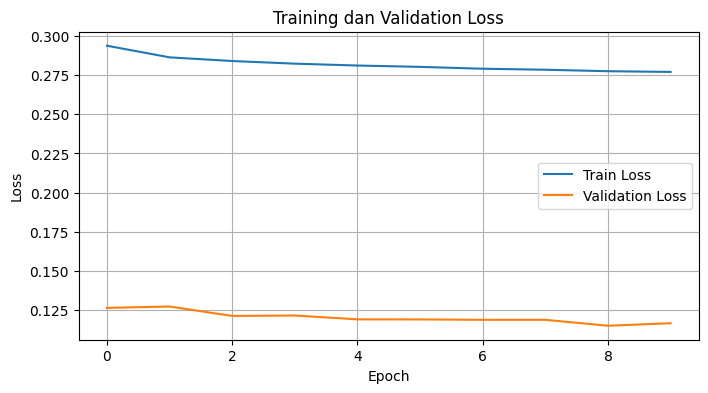

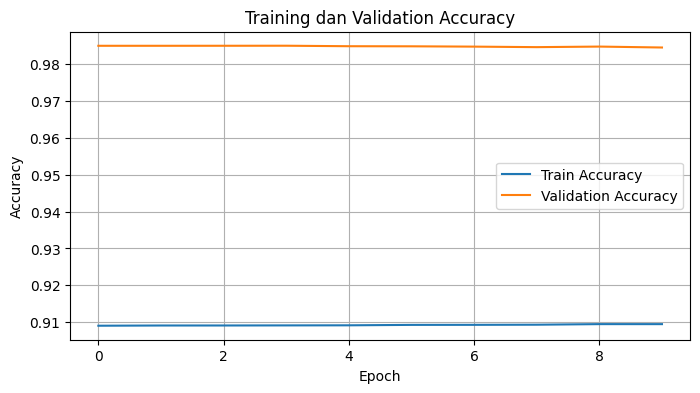

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training dan Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Cell 16 - Fungsi Evaluasi

In [31]:
def safe_metric(fn, y_true, y_score):
    try:
        return float(fn(y_true, y_score))
    except Exception:
        return np.nan


def classification_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    false_alarm_ratio = fp / (tp + fp) * 100 if (tp + fp) else 0.0

    return {
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_PPV': precision_score(y_true, y_pred, zero_division=0),
        'Recall_Sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'Specificity': specificity,
        'F1_score': f1_score(y_true, y_pred, zero_division=0),
        'AUROC': safe_metric(roc_auc_score, y_true, y_prob),
        'AUPRC': safe_metric(average_precision_score, y_true, y_prob),
        'False_Alarm_Ratio_percent': false_alarm_ratio,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }

## Cell 17 - Evaluasi Time-Level Threshold 0.5

In [32]:
y_prob_test = model.predict(
    X_test,
    verbose=0,
    batch_size=PREDICT_BATCH_SIZE
).ravel()

time_metrics_default = classification_metrics(
    y_test,
    y_prob_test,
    threshold=WARNING_THRESHOLD
)

time_metrics_df = pd.DataFrame([time_metrics_default]).T.rename(
    columns={0: 'Time-Level Result Threshold 0.5'}
)

time_metrics_df

,Time-Level Result Threshold 0.5
Threshold,0.500000
Accuracy,0.980602
Precision_PPV,0.111111
Recall_Sensitivity,0.002078
Specificity,0.999676
F1_score,0.004080
AUROC,0.680460
AUPRC,0.045250
False_Alarm_Ratio_percent,88.888889
TN,271446.000000


## Cell 18 - Threshold Tuning dari Validation Set
Threshold 0.5 tetap dipakai sebagai baseline paper. Threshold tuning dipakai sebagai eksperimen tambahan untuk menurunkan false alarm.

In [33]:
def threshold_sweep(y_true, y_prob):
    rows = []

    for threshold in np.arange(0.05, 0.96, 0.01):
        result = classification_metrics(
            y_true,
            y_prob,
            threshold=threshold
        )
        rows.append(result)

    return pd.DataFrame(rows)


y_prob_val = model.predict(
    X_val,
    verbose=0,
    batch_size=PREDICT_BATCH_SIZE
).ravel()

threshold_df = threshold_sweep(y_val, y_prob_val)

candidate_df = threshold_df[threshold_df['Recall_Sensitivity'] >= 0.50].copy()

if len(candidate_df) > 0:
    best_far_row = candidate_df.sort_values(
        ['False_Alarm_Ratio_percent', 'F1_score'],
        ascending=[True, False]
    ).iloc[0]
else:
    best_far_row = threshold_df.sort_values(
        'F1_score',
        ascending=False
    ).iloc[0]

TUNED_THRESHOLD = float(best_far_row['Threshold'])

print('TUNED_THRESHOLD:', TUNED_THRESHOLD)
print('Top 10 threshold berdasarkan F1-score:')
display(threshold_df.sort_values('F1_score', ascending=False).head(10))
print('Threshold terpilih:')
display(best_far_row.to_frame().T)

TUNED_THRESHOLD: 0.1
Top 10 threshold berdasarkan F1-score:


,Threshold,Accuracy,Precision_PPV,Recall_Sensitivity,Specificity,F1_score,AUROC,AUPRC,False_Alarm_Ratio_percent,TN,FP,FN,TP
19,0.24,0.963359,0.089169,0.154844,0.975753,0.113168,0.708604,0.049845,91.083100,157028,3902,2085,382
18,0.23,0.959956,0.084590,0.168221,0.972093,0.112573,0.708604,0.049845,91.540970,156439,4491,2052,415
17,0.22,0.956211,0.080980,0.183624,0.968054,0.112393,0.708604,0.049845,91.902038,155789,5141,2014,453
16,0.21,0.951902,0.076766,0.198216,0.963456,0.110671,0.708604,0.049845,92.323391,155049,5881,1978,489
20,0.25,0.965960,0.090500,0.138630,0.978643,0.109510,0.708604,0.049845,90.949987,157493,3437,2125,342
15,0.20,0.946602,0.072190,0.214025,0.957833,0.107964,0.708604,0.049845,92.780968,154144,6786,1939,528
14,0.19,0.940023,0.067477,0.231861,0.950879,0.104532,0.708604,0.049845,93.252330,153025,7905,1895,572
21,0.26,0.968482,0.091380,0.121605,0.981464,0.104348,0.708604,0.049845,90.862016,157947,2983,2167,300
13,0.18,0.932214,0.062862,0.250912,0.942658,0.100536,0.708604,0.049845,93.713821,151702,9228,1848,619
22,0.27,0.970544,0.092425,0.107823,0.983769,0.099532,0.708604,0.049845,90.757470,158318,2612,2201,266


Threshold terpilih:


,Threshold,Accuracy,Precision_PPV,Recall_Sensitivity,Specificity,F1_score,AUROC,AUPRC,False_Alarm_Ratio_percent,TN,FP,FN,TP
5,0.1,0.76666,0.035144,0.546413,0.770037,0.066041,0.708604,0.049845,96.485556,123922.0,37008.0,1119.0,1348.0


## Cell 19 - Bandingkan Threshold 0.5 vs Tuned Threshold

In [34]:
time_metrics_tuned = classification_metrics(
    y_test,
    y_prob_test,
    threshold=TUNED_THRESHOLD
)

time_metrics_compare = pd.DataFrame([
    {
        'Method': 'Threshold 0.5 Sesuai Paper',
        **time_metrics_default
    },
    {
        'Method': f'Tuned Threshold {TUNED_THRESHOLD:.2f}',
        **time_metrics_tuned
    }
])

time_metrics_compare

,Method,Threshold,Accuracy,Precision_PPV,Recall_Sensitivity,Specificity,F1_score,AUROC,AUPRC,False_Alarm_Ratio_percent,TN,FP,FN,TP
0,Threshold 0.5 Sesuai Paper,0.5,0.980602,0.111111,0.002078,0.999676,0.004080,0.68046,0.04525,88.888889,271446,88,5282,11
1,Tuned Threshold 0.10,0.1,0.765763,0.039643,0.484413,0.771248,0.073288,0.68046,0.04525,96.035746,209420,62114,2729,2564


## Cell 20 - Fungsi Warning dan Alert

In [35]:
def apply_warning_alert(
    probabilities,
    threshold=0.5,
    warning_count=3,
    window_size=5
):
    warnings = []
    alerts = []

    for i, prob in enumerate(probabilities):
        prob = 0.0 if pd.isna(prob) else float(prob)

        warning = bool(prob >= threshold)
        warnings.append(warning)

        start = max(0, i - window_size + 1)
        recent_warnings = warnings[start:i + 1]

        alert = bool(sum(recent_warnings) >= warning_count)
        alerts.append(alert)

    return warnings, alerts

## Cell 21 - Prediksi Patient-Level Cepat

In [36]:
def predict_patient_group_fast(g, threshold=0.5):
    g = g.sort_values('Hour').reset_index(drop=True).copy()
    g_norm = normalize_dataframe(g)

    probabilities = np.full(len(g), np.nan, dtype='float32')

    if len(g) >= WINDOW_SIZE:
        feature_values = g_norm[FEATURES].values.astype('float32')
        windows = []

        for i in range(WINDOW_SIZE - 1, len(g)):
            window = feature_values[i - WINDOW_SIZE + 1:i + 1]
            windows.append(window)

        X_patient = np.asarray(windows, dtype='float32')

        preds = model.predict(
            X_patient,
            verbose=0,
            batch_size=PREDICT_BATCH_SIZE
        ).reshape(-1)

        probabilities[WINDOW_SIZE - 1:] = preds

    probs_for_alarm = [
        0.0 if pd.isna(p) else float(p)
        for p in probabilities
    ]

    warnings_, alerts_ = apply_warning_alert(
        probs_for_alarm,
        threshold=threshold,
        warning_count=ALERT_WARNING_COUNT,
        window_size=ALERT_WINDOW_HOURS
    )

    out = g.copy()
    out['Sepsis_Probability'] = probabilities
    out['Warning'] = warnings_
    out['Alert'] = alerts_

    return out


def build_patient_level_predictions_fast(test_ids, threshold=0.5):
    rows = []
    hourly_outputs = []

    test_id_set = set(test_ids)
    test_df = processed_df[processed_df[PATIENT_COL].isin(test_id_set)].copy()

    if test_df.empty:
        raise ValueError('Data test kosong. Periksa test_ids atau processed_df.')

    test_df = test_df.sort_values([PATIENT_COL, 'Hour']).reset_index(drop=True)

    for pid, g in test_df.groupby(PATIENT_COL, sort=False):
        pred = predict_patient_group_fast(g, threshold=threshold)

        true_patient = int(pred[LABEL_COL].max())
        static_pred = int((pred['Sepsis_Probability'].fillna(0) >= threshold).any())
        alert_pred = int(pred['Alert'].any())

        valid_probs = pred['Sepsis_Probability'].dropna()
        max_prob = float(valid_probs.max()) if len(valid_probs) > 0 else 0.0

        first_warning_hour = (
            int(pred.loc[pred['Warning'] == True, 'Hour'].iloc[0])
            if pred['Warning'].any()
            else np.nan
        )

        first_alert_hour = (
            int(pred.loc[pred['Alert'] == True, 'Hour'].iloc[0])
            if pred['Alert'].any()
            else np.nan
        )

        rows.append({
            PATIENT_COL: pid,
            'True_Sepsis': true_patient,
            'Static_Threshold_Pred': static_pred,
            'SepsisAI_Alert_Pred': alert_pred,
            'Max_Probability': max_prob,
            'Any_Warning': bool(pred['Warning'].any()),
            'Any_Alert': bool(pred['Alert'].any()),
            'First_Warning_Hour': first_warning_hour,
            'First_Alert_Hour': first_alert_hour,
            'Total_Warnings': int(pred['Warning'].sum()),
            'Total_Alerts': int(pred['Alert'].sum()),
            'Total_Hours': int(len(pred))
        })

        hourly_outputs.append(pred)

    patient_pred_df = pd.DataFrame(rows)
    patient_hourly_pred_df = pd.concat(hourly_outputs, ignore_index=True)

    return patient_pred_df, patient_hourly_pred_df

## Cell 22 - Evaluasi Patient-Level

In [ ]:
def patient_level_metrics(df, pred_col):
    y_true = df['True_Sepsis'].values.astype(int)
    y_pred = df[pred_col].values.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    false_alarm_ratio = fp / (tp + fp) * 100 if (tp + fp) else 0.0

    return {
        'Method': pred_col,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_PPV': precision_score(y_true, y_pred, zero_division=0),
        'Recall_Sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'Specificity': specificity,
        'F1_score': f1_score(y_true, y_pred, zero_division=0),
        'False_Alarm_Ratio_percent': false_alarm_ratio,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }


print('Membangun patient-level result threshold 0.5...')
patient_pred_df_05, patient_hourly_pred_df_05 = build_patient_level_predictions_fast(
    test_ids,
    threshold=WARNING_THRESHOLD
)

patient_metrics_05 = pd.DataFrame([
    patient_level_metrics(patient_pred_df_05, 'Static_Threshold_Pred'),
    patient_level_metrics(patient_pred_df_05, 'SepsisAI_Alert_Pred')
])

print('Patient-Level Result Threshold 0.5:')
display(patient_metrics_05)

print('Membangun patient-level result tuned threshold...')
patient_pred_df_tuned, patient_hourly_pred_df_tuned = build_patient_level_predictions_fast(
    test_ids,
    threshold=TUNED_THRESHOLD
)

patient_metrics_tuned = pd.DataFrame([
    patient_level_metrics(patient_pred_df_tuned, 'Static_Threshold_Pred'),
    patient_level_metrics(patient_pred_df_tuned, 'SepsisAI_Alert_Pred')
])

print('Patient-Level Result Tuned Threshold:')
display(patient_metrics_tuned)

Membangun patient-level result threshold 0.5...
Patient-Level Result Threshold 0.5:


,Method,Accuracy,Precision_PPV,Recall_Sensitivity,Specificity,F1_score,False_Alarm_Ratio_percent,TN,FP,FN,TP
0,Static_Threshold_Pred,0.868969,0.346154,0.038961,0.989328,0.070039,65.384615,1576,17,222,9
1,SepsisAI_Alert_Pred,0.871162,0.357143,0.021645,0.994350,0.040816,64.285714,1584,9,226,5


Membangun patient-level result tuned threshold...


## Cell 23 - Gabungkan Hasil Patient-Level

In [ ]:
patient_metrics_05_display = patient_metrics_05.copy()
patient_metrics_05_display['Threshold_Type'] = 'Threshold 0.5 Sesuai Paper'

patient_metrics_tuned_display = patient_metrics_tuned.copy()
patient_metrics_tuned_display['Threshold_Type'] = f'Tuned Threshold {TUNED_THRESHOLD:.2f}'

patient_metrics_compare = pd.concat(
    [patient_metrics_05_display, patient_metrics_tuned_display],
    ignore_index=True
)

patient_metrics_compare = patient_metrics_compare[
    [
        'Threshold_Type',
        'Method',
        'Accuracy',
        'Precision_PPV',
        'Recall_Sensitivity',
        'Specificity',
        'F1_score',
        'False_Alarm_Ratio_percent',
        'TN',
        'FP',
        'FN',
        'TP'
    ]
]

patient_metrics_compare

## Cell 24 - Grafik Risk Profile Pasien

In [ ]:
def plot_patient_risk(patient_hourly_df, patient_id=None, threshold=0.5):
    if patient_id is None:
        patient_id = patient_hourly_df[PATIENT_COL].iloc[0]

    g = patient_hourly_df[patient_hourly_df[PATIENT_COL] == patient_id].sort_values('Hour')

    plt.figure(figsize=(10, 4))
    plt.plot(
        g['Hour'],
        g['Sepsis_Probability'],
        marker='o',
        label='Sepsis Probability'
    )

    plt.axhline(
        threshold,
        linestyle='--',
        label=f'Threshold {threshold:.2f}'
    )

    warning_points = g[g['Warning'] == True]
    alert_points = g[g['Alert'] == True]

    if len(warning_points) > 0:
        plt.scatter(
            warning_points['Hour'],
            warning_points['Sepsis_Probability'],
            s=80,
            label='Warning'
        )

    if len(alert_points) > 0:
        plt.scatter(
            alert_points['Hour'],
            alert_points['Sepsis_Probability'],
            s=120,
            marker='x',
            label='Alert'
        )

    plt.title(f'Risk Profile Pasien: {patient_id}')
    plt.xlabel('Hour')
    plt.ylabel('Sepsis Probability')
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()


# Contoh plot pasien dengan alert jika ada. Jika tidak ada, ambil pasien pertama.
alert_patients = patient_pred_df_05[patient_pred_df_05['Any_Alert'] == True]

if len(alert_patients) > 0:
    example_pid = alert_patients[PATIENT_COL].iloc[0]
else:
    example_pid = patient_pred_df_05[PATIENT_COL].iloc[0]

plot_patient_risk(patient_hourly_pred_df_05, example_pid, threshold=WARNING_THRESHOLD)

## Cell 25 - Simpan Hasil ke Google Drive

In [ ]:
model_path = os.path.join(ARTIFACT_DIR, 'final_lstm_sepsis_uas.keras')
model.save(model_path)

time_metrics_path = os.path.join(ARTIFACT_DIR, 'time_level_metrics_compare.csv')
patient_metrics_path = os.path.join(ARTIFACT_DIR, 'patient_level_metrics_compare.csv')

patient_pred_05_path = os.path.join(ARTIFACT_DIR, 'patient_level_predictions_threshold_05.csv')
patient_hourly_05_path = os.path.join(ARTIFACT_DIR, 'patient_hourly_predictions_threshold_05.csv')

patient_pred_tuned_path = os.path.join(ARTIFACT_DIR, 'patient_level_predictions_tuned.csv')
patient_hourly_tuned_path = os.path.join(ARTIFACT_DIR, 'patient_hourly_predictions_tuned.csv')

config_path = os.path.join(ARTIFACT_DIR, 'config.json')

time_metrics_compare.to_csv(time_metrics_path, index=False)
patient_metrics_compare.to_csv(patient_metrics_path, index=False)

patient_pred_df_05.to_csv(patient_pred_05_path, index=False)
patient_hourly_pred_df_05.to_csv(patient_hourly_05_path, index=False)

patient_pred_df_tuned.to_csv(patient_pred_tuned_path, index=False)
patient_hourly_pred_df_tuned.to_csv(patient_hourly_tuned_path, index=False)

config = {
    'DATA_ZIP_PATH': DATA_ZIP_PATH,
    'EXTRACT_DIR': EXTRACT_DIR,
    'ARTIFACT_DIR': ARTIFACT_DIR,
    'WINDOW_SIZE': WINDOW_SIZE,
    'WARNING_THRESHOLD': WARNING_THRESHOLD,
    'TUNED_THRESHOLD': TUNED_THRESHOLD,
    'ALERT_WARNING_COUNT': ALERT_WARNING_COUNT,
    'ALERT_WINDOW_HOURS': ALERT_WINDOW_HOURS,
    'EPOCHS': EPOCHS,
    'BATCH_SIZE': BATCH_SIZE,
    'NEG_POS_RATIO': NEG_POS_RATIO,
    'FEATURES': FEATURES
}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)

print('File berhasil disimpan:')
print(model_path)
print(time_metrics_path)
print(patient_metrics_path)
print(patient_pred_05_path)
print(patient_hourly_05_path)
print(patient_pred_tuned_path)
print(patient_hourly_tuned_path)
print(config_path)

## Cell 26 - Web Gradio
Web menggunakan threshold 0.5 sebagai default karena sesuai paper SepsisAI.

In [ ]:
import gradio as gr


def fig_patient_risk(patient_hourly_df, patient_id, threshold=0.5):
    g = patient_hourly_df[patient_hourly_df[PATIENT_COL] == patient_id].sort_values('Hour')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(g['Hour'], g['Sepsis_Probability'], marker='o', label='Sepsis Probability')
    ax.axhline(threshold, linestyle='--', label=f'Threshold {threshold:.2f}')

    warning_points = g[g['Warning'] == True]
    alert_points = g[g['Alert'] == True]

    if len(warning_points) > 0:
        ax.scatter(
            warning_points['Hour'],
            warning_points['Sepsis_Probability'],
            s=80,
            label='Warning'
        )

    if len(alert_points) > 0:
        ax.scatter(
            alert_points['Hour'],
            alert_points['Sepsis_Probability'],
            s=120,
            marker='x',
            label='Alert'
        )

    ax.set_title(f'Risk Profile Pasien: {patient_id}')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Sepsis Probability')
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend()

    return fig


def summarize_patient(patient_id, threshold_type):
    if threshold_type == 'Threshold 0.5 sesuai paper':
        pred_df = patient_pred_df_05
        hourly_df = patient_hourly_pred_df_05
        threshold = WARNING_THRESHOLD
    else:
        pred_df = patient_pred_df_tuned
        hourly_df = patient_hourly_pred_df_tuned
        threshold = TUNED_THRESHOLD

    row = pred_df[pred_df[PATIENT_COL] == patient_id].iloc[0]
    g = hourly_df[hourly_df[PATIENT_COL] == patient_id].sort_values('Hour')

    if bool(row['Any_Alert']):
        status = 'ALERT'
        recommendation = 'Risiko sepsis tinggi menurut aturan warning-alert. Pasien perlu diprioritaskan untuk evaluasi klinis.'
    elif bool(row['Any_Warning']):
        status = 'WARNING'
        recommendation = 'Risiko mulai meningkat. Pasien perlu dipantau lebih ketat dalam beberapa jam berikutnya.'
    else:
        status = 'NORMAL'
        recommendation = 'Belum ada warning atau alert berdasarkan trajectory risiko pasien.'

    status_text = f"""
## Status Pasien: {status}

**Patient ID:** {patient_id}
**True Sepsis:** {int(row['True_Sepsis'])}
**Max Probability:** {float(row['Max_Probability']):.4f}
**Any Warning:** {bool(row['Any_Warning'])}
**Any Alert:** {bool(row['Any_Alert'])}
**First Warning Hour:** {row['First_Warning_Hour']}
**First Alert Hour:** {row['First_Alert_Hour']}

**Rekomendasi sistem:**
{recommendation}

**Aturan:** warning jika probabilitas >= {threshold:.2f}; alert jika ada {ALERT_WARNING_COUNT} warning dalam {ALERT_WINDOW_HOURS} jam.
"""

    fig = fig_patient_risk(hourly_df, patient_id, threshold=threshold)

    show_cols = [PATIENT_COL, 'Hour', LABEL_COL, 'Sepsis_Probability', 'Warning', 'Alert']
    return status_text, g[show_cols], fig


def predict_uploaded_csv(file, threshold_type):
    if file is None:
        return 'Upload file CSV terlebih dahulu.', pd.DataFrame(), None

    uploaded_raw = pd.read_csv(file.name)
    uploaded_processed = preprocess_dataframe(uploaded_raw)

    if threshold_type == 'Threshold 0.5 sesuai paper':
        threshold = WARNING_THRESHOLD
    else:
        threshold = TUNED_THRESHOLD

    # Jika CSV berisi beberapa Patient_ID, pakai pasien pertama untuk demo.
    pid = uploaded_processed[PATIENT_COL].iloc[0]
    g = uploaded_processed[uploaded_processed[PATIENT_COL] == pid].copy()
    pred = predict_patient_group_fast(g, threshold=threshold)

    any_warning = bool(pred['Warning'].any())
    any_alert = bool(pred['Alert'].any())
    max_prob = float(pred['Sepsis_Probability'].dropna().max()) if pred['Sepsis_Probability'].notna().any() else 0.0

    if any_alert:
        status = 'ALERT'
        recommendation = 'Risiko sepsis tinggi menurut aturan warning-alert. Pasien perlu diprioritaskan untuk evaluasi klinis.'
    elif any_warning:
        status = 'WARNING'
        recommendation = 'Risiko mulai meningkat. Pasien perlu dipantau lebih ketat.'
    else:
        status = 'NORMAL'
        recommendation = 'Belum ada warning atau alert berdasarkan trajectory risiko pasien.'

    status_text = f"""
## Status CSV Upload: {status}

**Patient ID:** {pid}
**Max Probability:** {max_prob:.4f}
**Any Warning:** {any_warning}
**Any Alert:** {any_alert}

**Rekomendasi sistem:**
{recommendation}
"""

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(pred['Hour'], pred['Sepsis_Probability'], marker='o', label='Sepsis Probability')
    ax.axhline(threshold, linestyle='--', label=f'Threshold {threshold:.2f}')
    ax.set_title(f'Risk Profile Upload CSV: {pid}')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Sepsis Probability')
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend()

    show_cols = [PATIENT_COL, 'Hour', LABEL_COL, 'Sepsis_Probability', 'Warning', 'Alert']
    return status_text, pred[show_cols], fig


patient_choices = patient_pred_df_05[PATIENT_COL].astype(str).tolist()

with gr.Blocks(title='SepsisAI Mini UAS') as app:
    gr.Markdown("""
# SepsisAI Mini - Web Prediksi Risiko Sepsis

Prototype UAS Data Mining Kesehatan berbasis paper SepsisAI.
Model menggunakan LSTM untuk menghasilkan probabilitas risiko sepsis, lalu sistem memberi warning-alert.

**Catatan:** prototype ini untuk demo akademik, bukan alat diagnosis medis.
""")

    with gr.Tab('Pilih Pasien Test'):
        threshold_type = gr.Radio(
            choices=['Threshold 0.5 sesuai paper', f'Tuned Threshold {TUNED_THRESHOLD:.2f}'],
            value='Threshold 0.5 sesuai paper',
            label='Mode Threshold'
        )

        patient_dropdown = gr.Dropdown(
            choices=patient_choices,
            value=patient_choices[0] if patient_choices else None,
            label='Pilih Patient ID'
        )

        run_button = gr.Button('Tampilkan Prediksi')
        status_output = gr.Markdown()
        table_output = gr.Dataframe()
        plot_output = gr.Plot()

        run_button.click(
            fn=summarize_patient,
            inputs=[patient_dropdown, threshold_type],
            outputs=[status_output, table_output, plot_output]
        )

    with gr.Tab('Upload CSV Pasien'):
        upload_threshold_type = gr.Radio(
            choices=['Threshold 0.5 sesuai paper', f'Tuned Threshold {TUNED_THRESHOLD:.2f}'],
            value='Threshold 0.5 sesuai paper',
            label='Mode Threshold'
        )
        file_input = gr.File(label='Upload CSV Pasien')
        upload_button = gr.Button('Prediksi CSV')
        upload_status = gr.Markdown()
        upload_table = gr.Dataframe()
        upload_plot = gr.Plot()

        upload_button.click(
            fn=predict_uploaded_csv,
            inputs=[file_input, upload_threshold_type],
            outputs=[upload_status, upload_table, upload_plot]
        )

app.launch(share=True)